# Niche Query on CCF Dataset


Experiment setup:
- Niche: k-hop neighboring cells within the same brain section;
- Niche: all neighboring cells within the same brain section;
- Niche: cross brain section k-hop neighbouring cells;
- Positive pairs: samples from the same brain section and visualization by prob.

## Load Data

In [1]:

import logging

# sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
logging.basicConfig(level=logging.INFO)

## QueST Embedding

In [6]:
# load data
import numpy as np
import pandas as pd
import torch
import os
import scanpy as sc


def load_emb(adata_folder, emb_folder, emb_key, suffix='pt', update_anndata=True):
    adata_list = []
    fnames = [fname for fname in os.listdir(adata_folder)]
    fnames.sort()
    for fname in fnames:
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)

        emb_path = os.path.join(emb_folder, f"{stem}.{suffix}")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        if suffix == 'csv':
            emb = pd.read_csv(emb_path, index_col=0).values.astype(np.float64)
        elif suffix == 'pt':
            emb_tensor = torch.load(emb_path, map_location="cpu")
            emb = emb_tensor.detach().cpu().numpy()
        else:
            raise ValueError(f"Unknown suffix {suffix}")

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        if update_anndata:
            adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = '/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/notebook/ccf/data/benchmark_samples/20260329_224339'
emb_folder = '/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_zhuang_abca_1_0329'
embedding_key = 'X_quest_emb'
adata_list = load_emb(adata_folder, emb_folder, emb_key=embedding_key, suffix='pt')

[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_zhuang_abca_1_0329/Zhuang-ABCA-1.084.pt
[DONE] Zhuang-ABCA-1.084
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_zhuang_abca_1_0329/Zhuang-ABCA-1.086.pt
[DONE] Zhuang-ABCA-1.086
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_zhuang_abca_1_0329/Zhuang-ABCA-1.087.pt
[DONE] Zhuang-ABCA-1.087
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_zhuang_abca_1_0329/Zhuang-ABCA-1.088.pt
[DONE] Zhuang-ABCA-1.088
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_zhuang_abca_1_0329/Zhuang-ABCA-1.090.pt
[DONE] Zhuang-ABCA-1.090
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_zhuang_abca_1_0

In [5]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery
import os

# step 1: create db
data_folder = 'notebook/ccf/data/zhuang-abca-1/'
target_sample_ids = ['Zhuang-ABCA-1.086', 'Zhuang-ABCA-1.104', 'Zhuang-ABCA-1.102', 'Zhuang-ABCA-1.087',
                  'Zhuang-ABCA-1.090', 'Zhuang-ABCA-1.093', 'Zhuang-ABCA-1.084', 'Zhuang-ABCA-1.088',
                  'Zhuang-ABCA-1.096', 'Zhuang-ABCA-1.097', 'Zhuang-ABCA-1.106', 'Zhuang-ABCA-1.107']
adata_paths = [os.path.join(adata_folder, sample_id) for sample_id in target_sample_ids ]
db = Database(target_sample_ids)
db.construct(adata_path=adata_paths,
             cell_metadata_path=[data_folder + 'cell_metadata.csv'],
             ccf_coordinates_path=[data_folder + 'ccf_coordinates.csv'],
             feature_name=embedding_key,
             parcellation_path='notebook/ccf/data/parcellation/structure.json')

INFO:src.NicheQueryPrototype.database:Loading adata...
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Constructing parcellation tree...
INFO:src.NicheQueryPrototype.database:Constructing database for niche query...
INFO:src.NicheQueryPrototype.database:	10000 cells loaded...
INFO:src.NicheQueryPrototype.database:	20000 cells loaded...
INFO:src.NicheQueryPrototype.database:	30000 cells loaded...
INFO:src.NicheQueryPrototype.database:	40000 cells loaded...
INFO:src.NicheQueryPrototype.database:	50000 cells loaded...
INFO:src.NicheQueryPrototype.database:	60000 cells loaded...
INFO:src.NicheQueryPrototype.database:	70000 cells loaded...
INFO:src.NicheQueryPrototype.database:	80000 cells loaded...
INFO:src.NicheQueryPrototype.database:	90000 cells loaded...
INFO:src.NicheQueryPrototype.database:	100000 cells loaded...
INFO:src.NicheQueryPrototype.database:	110000 cells loaded...
INFO:src.NicheQueryPrototype.database:	120000 cells loaded

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.086 slice.
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:143: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'sample_id' as categorical


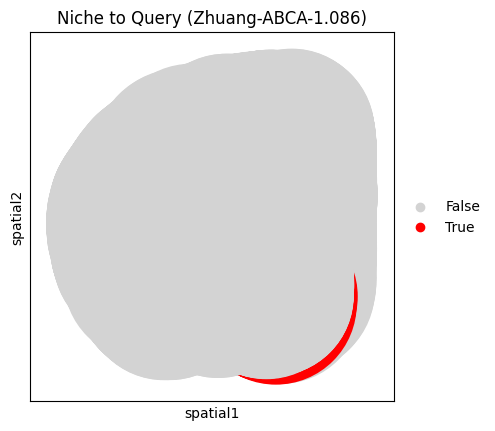

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:149: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


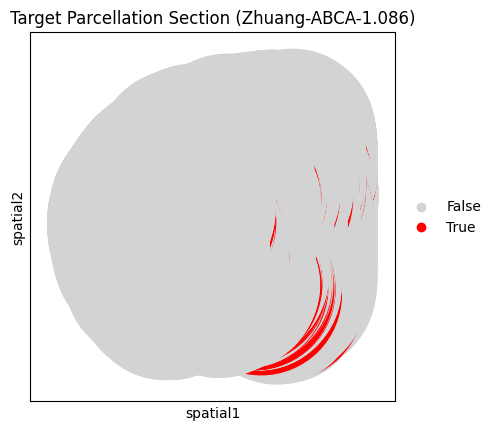

In [6]:
# step 2: construct niche to query

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='44271692540130311954709901940577285312', sample_id='Zhuang-ABCA-1.086', k=10, cell_limit=100, parcellation_index=987)
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr

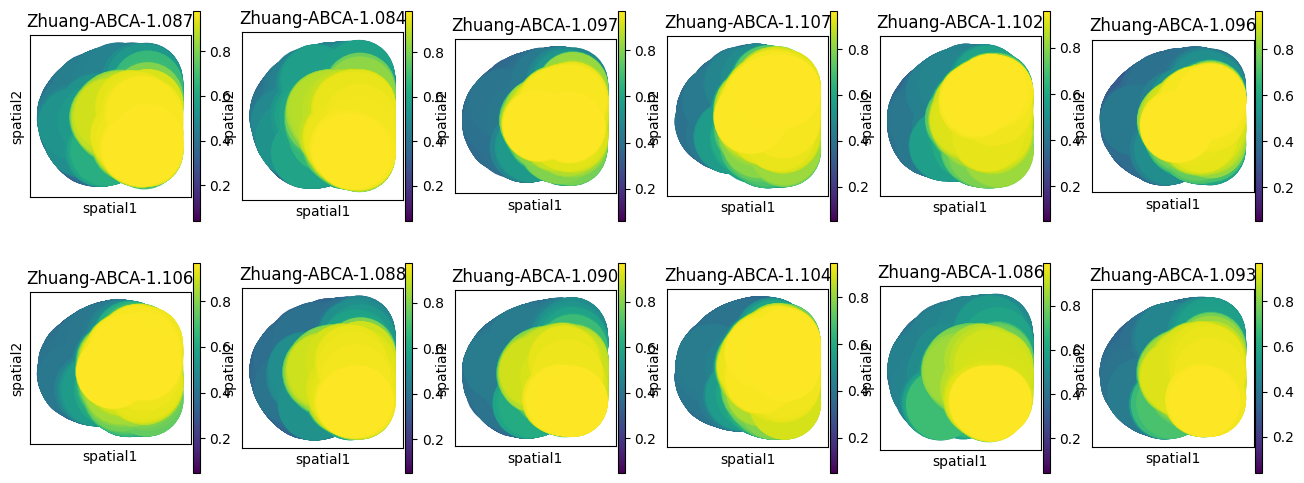

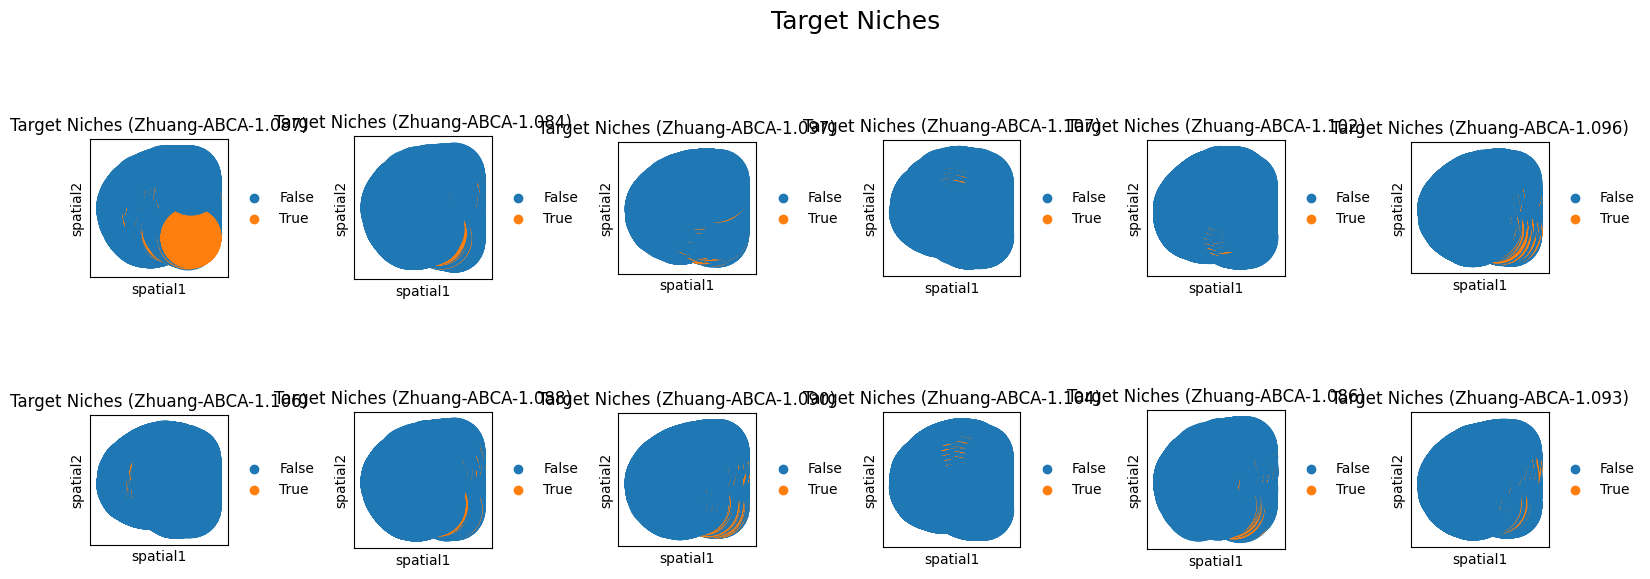

In [7]:
# step 3: run niche query on given samples

niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.niche_query_visualization(query_samples, show_target_niches=True)

In [8]:
# step 4: classification report
niche_query.niche_query_verification(search_samples=query_samples)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 32006 and the array at index 1 has size 25244

## Gene Expressions

In [ ]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery

# step 1: create db
data_folder = 'notebook/ccf/data/zhuang-abca-1/'
# target_sample_ids = ['Zhuang-ABCA-1.064', 'Zhuang-ABCA-1.061', 'Zhuang-ABCA-1.060', 'Zhuang-ABCA-1.058',
#                   'Zhuang-ABCA-1.062', 'Zhuang-ABCA-1.057', 'Zhuang-ABCA-1.059', 'Zhuang-ABCA-1.066',
#                   'Zhuang-ABCA-1.063', 'Zhuang-ABCA-1.065', 'Zhuang-ABCA-1.067', 'Zhuang-ABCA-1.056']
target_sample_ids = ['Zhuang-ABCA-1.086','Zhuang-ABCA-1.104','Zhuang-ABCA-1.102']
db = Database(target_sample_ids)
db.construct(adata_path=[data_folder + 'Zhuang-ABCA-1-raw.h5ad'],
             cell_metadata_path=[data_folder + 'cell_metadata.csv'],
             ccf_coordinates_path=[data_folder + 'ccf_coordinates.csv'],
             feature_name='gene_expression',
             parcellation_path='notebook/ccf/data/parcellation/structure.json')

# (optional) download sample slices
# db.export_sample_adata('notebook/ccf/data/benchmark_samples_l2')

INFO:src.NicheQueryPrototype.database:Loading adata...


Highlighted cells (n=8) for parcellation 826 in sample 'Zhuang-ABCA-1.064':
  cell_id='277552981985634116352617179774800842258'  x=5.098450611281249  y=5.35012044066692  parcellation_index=904
  cell_id='47229962583602989777480122159003394352'  x=5.104659449205433  y=5.354949924054181  parcellation_index=904
  cell_id='66937628189021120412060129425568985273'  x=5.107494382916546  y=5.3603716932257  parcellation_index=904
  cell_id='68427160749867949130340749813809498637'  x=5.093061774582461  y=5.354259070134931  parcellation_index=904
  cell_id='308230477101150044220762502682864893659'  x=5.03634487798764  y=5.335035753810991  parcellation_index=904
  cell_id='164539944713990851591482380858968030350'  x=5.109065960032543  y=5.295191817512567  parcellation_index=904
  cell_id='180982964620303110098876138817330645069'  x=5.081861575261545  y=5.2997093209641095  parcellation_index=904
  cell_id='198061190760642462328223461970225340953'  x=5.092858615198923  y=5.297513620998721  parcellat

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:305: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


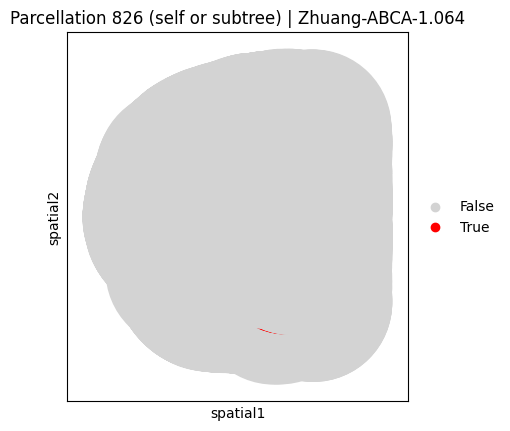

In [ ]:
target_parcellation = 825

db.visualize_parcellation_cells(
    sample_id="Zhuang-ABCA-0.086",
    target_parcellation_index=target_parcellation,
    print_metadata=True,
)

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 99 cells on Zhuang-ABCA-1.064 slice.
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:146: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'sample_id' as categorical


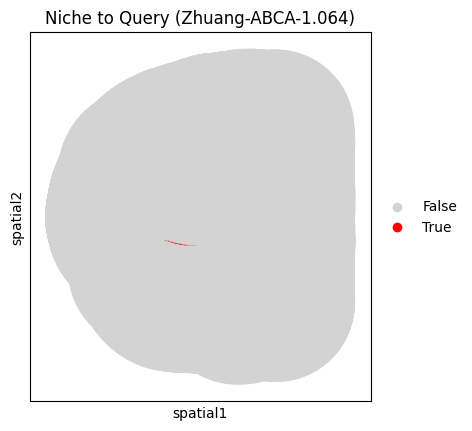

In [3]:
# step 2: construct niche to query; 44271692540130311954709901940577285312

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='', sample_id='Zhuang-ABCA-1.064', k=10, cell_limit=100, parcellation_index=567)
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr

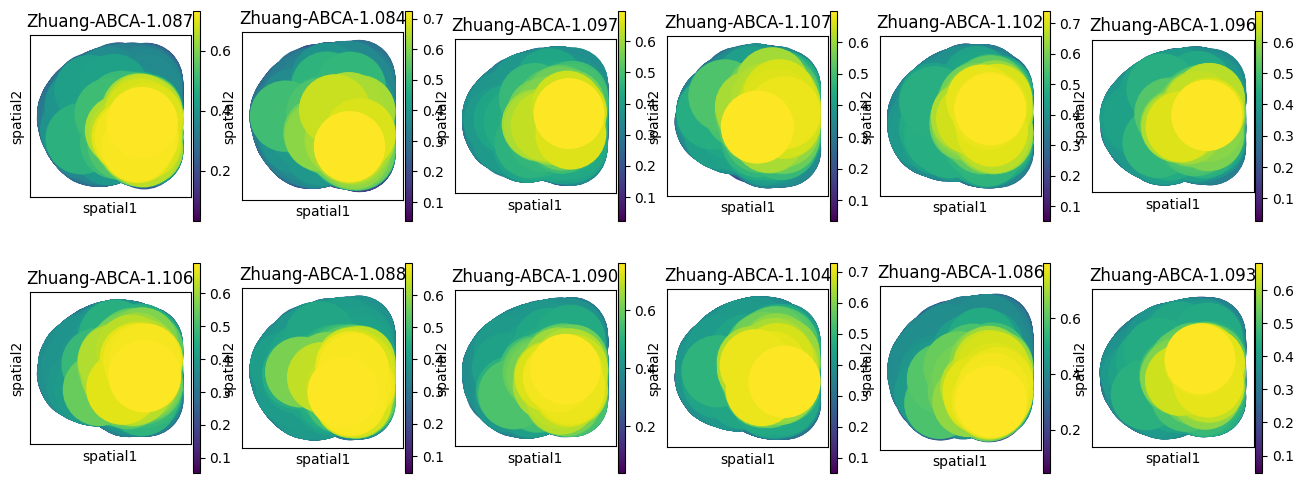

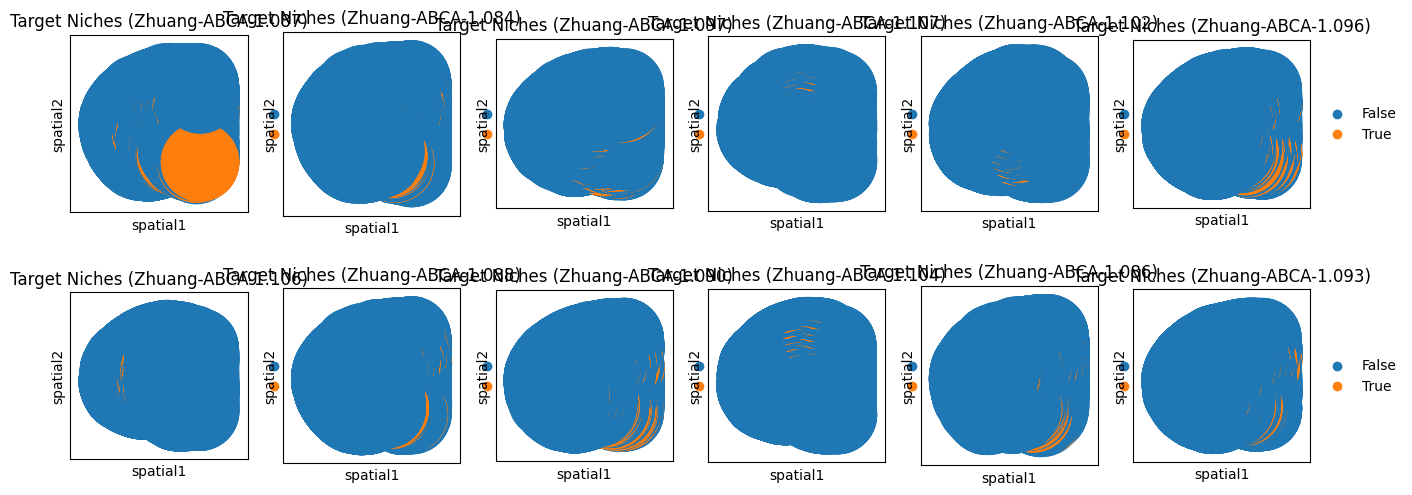

In [7]:
# step 3: run niche query on given samples

niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.niche_query_visualization(query_samples, show_target_niches=True)

In [10]:
# step 4: classification report
niche_query.niche_query_verification(search_samples=query_samples)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr